In [3]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, 
                            roc_auc_score, 
                            average_precision_score, 
                            precision_score, 
                            recall_score, 
                            f1_score)
from sklearn.ensemble import RandomForestClassifier
from lifelines import KaplanMeierFitter

# Data Model Preparation

In [14]:
#load the final clean merged file
merged_df = pd.read_csv("data/merged_data.csv.gz",compression="gzip")

In [15]:
#determine the primary target
target_col = "closed_within_1yr"

#overall closure stats
#shows the number of closures across different definitions
print(merged_df[["closed_in_year","closed_within_1yr","closed_within_2yr"]].sum())
#count how many no closure and closure within 1 year
print(merged_df[target_col].value_counts(dropna=False))
#shows mean of % of hospitals that closed within 1 year
print(merged_df[target_col].mean())
#shows how many hospitals closed within 1 year in each year
print(merged_df.groupby("year")["closed_within_1yr"].sum())

closed_in_year       21
closed_within_1yr    58
closed_within_2yr    99
dtype: int64
closed_within_1yr
0    26419
1       58
Name: count, dtype: int64
0.002190580503833516
year
2013    7
2014    6
2015    7
2016    5
2017    5
2018    8
2019    5
2020    2
2021    1
2022    4
2023    8
Name: closed_within_1yr, dtype: int64


Due to low closure rates of hospitals, we defined a primary and secondary target to better capture short\-term and longer\-term risk\. 

In [16]:
#define both prediction targets
primary_target = "closed_within_1yr"
secondary_target = "closed_within_2yr"

print("Primary Target: Closed Within 1 Year")
print(merged_df[primary_target].value_counts(dropna=False))
print(merged_df[primary_target].mean())
print(merged_df.groupby("year")[primary_target].sum())

print("Secondary Target: Closed Within 2 Year")
print(merged_df[secondary_target].value_counts(dropna=False))
print(merged_df[secondary_target].mean())
print(merged_df.groupby("year")[secondary_target].sum())

Primary Target: Closed Within 1 Year
closed_within_1yr
0    26419
1       58
Name: count, dtype: int64
0.002190580503833516
year
2013    7
2014    6
2015    7
2016    5
2017    5
2018    8
2019    5
2020    2
2021    1
2022    4
2023    8
Name: closed_within_1yr, dtype: int64
Secondary Target: Closed Within 2 Year
closed_within_2yr
0    26378
1       99
Name: count, dtype: int64
0.003739094308267553
year
2013    13
2014    12
2015    10
2016     9
2017    11
2018    12
2019     6
2020     4
2021     5
2022     8
2023     9
Name: closed_within_2yr, dtype: int64


In [17]:
#feature cleaning
#drop identifier, matching, and non predictive columns
drop_columns = ["rpt_rec_num",
            "Provider CCN",
            "Hospital Name",
            "Street Address",
            "City_cp",
            "State Code",
            "Zip Code",
            "Count",
            "Hospital",
            "Address",
            "City_unc",
            "State",
            "Zip",
            "County/district",
            "RUCA",
            "CBSA",
            "Medicare Payment",
            "# of Beds",
            "Closure Month",
            "Closure Year",
            "Complete Closure (0);\nConverted Closure (1)",
            "updated 10/1/2025",
            "match_hospital_cp",
            "match_city_cp",
            "match_state",
            "match_address_cp",
            "match_zip_cp",
            "match_hospital_std",
            "match_hospital_unc",
            "match_city_unc",
            "match_address_unc",
            "match_zip_unc",
            "hospital_exact_flag",
            "city_match_flag",
            "address_match_flag",
            "zip_match_flag",
            "closure_flag",
            "FAC_NAME"]
#keep columns that are not in the above list
drop_cols_existing = []
for col in drop_columns:
    if col in merged_df.columns:
        drop_cols_existing.append(col)
#create the base modeling dataset after removing the columns above
base_model_df = merged_df.drop(columns=drop_cols_existing).copy()

In [18]:
#check for missing values
#sum missing data across all columns
missing_summary = base_model_df.isna().sum().reset_index()
#rename columns for clarity
missing_summary.columns = ["column","missing_count"]
#calc the % of missing values for each column
missing_summary["missing_pct"] = missing_summary["missing_count"]/len(base_model_df)
#sort columns from most to least missing
missing_summary = missing_summary.sort_values("missing_pct",ascending = False)
missing_summary

,column,missing_count,missing_pct
86,DRG Amounts Other Than Outlier Payments,26228,0.990596
21,Hospital Total Days Title V For Adults & Peds,25893,0.977943
16,Total Discharges Title V,25879,0.977414
27,Hospital Total Discharges Title V For Adults &...,25879,0.977414
10,Total Days Title V,25830,0.975564
...,...,...,...
36,Overhead Non-Salary Costs,0,0.000000
38,Total Costs,0,0.000000
5,Type of Control,0,0.000000
41,Combined Outpatient + Inpatient Total Charges,0,0.000000


# Modeling

### Create Financial Ratios

In [19]:
#create financial ratios
#operating margin - core financial health
base_model_df["operating_margin"] = (base_model_df["Net Income from Service to Patients"]/base_model_df["Net Patient Revenue"].replace(0,np.nan))
#total margin - overall sustainability
base_model_df["total_margin"] = (base_model_df["Net Income"]/base_model_df["Total Income"].replace(0,np.nan))
#cost efficiency
base_model_df["cost_to_revenue"] = (base_model_df["Total Costs"]/base_model_df["Total Patient Revenue"].replace(0,np.nan))
#liquidity
base_model_df["current_ratio"] = (base_model_df["Total Current Assets"]/base_model_df["Total Current Liabilities"].replace(0,np.nan))
base_model_df["cash_ratio"] = (base_model_df["Cash on Hand and in Banks"]/base_model_df["Total Current Liabilities"].replace(0,np.nan))
#leverage
base_model_df["debt_ratio"] = (base_model_df["Total Liabilities"]/base_model_df["Total Assets"].replace(0,np.nan))
base_model_df["equity_ratio"] = (base_model_df["Total Fund Balances"]/base_model_df["Total Assets"].replace(0,np.nan))
#utilization
base_model_df["occupancy_rate"] = (base_model_df["Total Days (V + XVIII + XIX + Unknown)"]/base_model_df["Total Bed Days Available"].replace(0,np.nan))
base_model_df["avg_length_of_stay"] = (base_model_df["Total Days (V + XVIII + XIX + Unknown)"]/base_model_df["Total Discharges (V + XVIII + XIX + Unknown)"].replace(0,np.nan))
#payor mix
base_model_df["medicaid_share"] = (base_model_df["Net Revenue from Medicaid"]/base_model_df["Total Patient Revenue"].replace(0,np.nan))
#uncompensated care
base_model_df["uncompensated_care_ratio"] = (base_model_df["Cost of Uncompensated Care"]/base_model_df["Total Costs"].replace(0,np.nan))
#labor intensity
base_model_df["labor_cost_ratio"] = (base_model_df["Total Salaries (adjusted)"]/base_model_df["Total Costs"].replace(0,np.nan))

#fix inf/NaN
base_model_df = base_model_df.replace([np.inf,-np.inf], np.nan)
print("Missing after feature creation:", base_model_df.isna().sum().sum())

Missing after feature creation: 859982


### Identify Missing Values

In [20]:
#define target variables to exclude from preprocessing steps
target_cols = ["closed_in_year","closed_within_1yr","closed_within_2yr"]
#confirm target variables are numberic and properly formatted
for col in target_cols:
    if col in base_model_df.columns:
        base_model_df[col] = pd.to_numeric(base_model_df[col], errors="coerce").astype(int)

print("Remaining missing values before train/test:", base_model_df.isna().sum().sum())

Remaining missing values before train/test: 859982


## Logistic Modeling

In [21]:
#create primary model dataset
primary_df = base_model_df.copy()
#remove other target variables
primary_df = primary_df.drop(columns = ["closed_in_year","closed_within_2yr"],
                                errors = "ignore")
#create secondary model dataset
secondary_df = base_model_df.copy()
#remove other target variables
secondary_df = secondary_df.drop(columns = ["closed_in_year","closed_within_1yr"],
                                errors = "ignore")

In [22]:
#primary train/test split
primary_train_df = primary_df[primary_df["year"] < 2020].copy()
primary_test_df = primary_df[primary_df["year"] >= 2020].copy()
#secondary train/test split
secondary_train_df = secondary_df[secondary_df["year"] < 2020].copy()
secondary_test_df = secondary_df[secondary_df["year"] >= 2020].copy()

### Handling Missing Values in Primary and Secondary Datasets

In [23]:
#primary modeling
#create separate predictors and target
X_train_primary = primary_train_df.drop(columns=[primary_target]).copy()
y_train_primary = primary_train_df[primary_target].copy()

X_test_primary = primary_test_df.drop(columns=[primary_target]).copy()
y_test_primary = primary_test_df[primary_target].copy()
#year is used to define train/test
X_train_primary = X_train_primary.drop(columns=["year"], errors="ignore")
X_test_primary = X_test_primary.drop(columns=["year"], errors="ignore")
#calc % missing for each training columns
primary_missing_summary = X_train_primary.isna().sum().reset_index()
primary_missing_summary.columns = ["column", "missing_count"]
primary_missing_summary["missing_pct"] = primary_missing_summary["missing_count"]/len(X_train_primary)
#drop anything that came back >80% missing
missing_threshold = 0.80
#loop through each column and check its missing %
primary_high_missing_cols = []
for i in range(len(primary_missing_summary)):
    col = primary_missing_summary.loc[i,"column"]
    pct = primary_missing_summary.loc[i,"missing_pct"]
    if pct>missing_threshold and col != "closed_within_1yr":
        primary_high_missing_cols.append(col)
#remove high missing columns from train/test
X_train_primary = X_train_primary.drop(columns = primary_high_missing_cols, errors="ignore")
X_test_primary = X_test_primary.drop(columns = primary_high_missing_cols, errors="ignore")
#recalc % missing for each training columns
primary_missing_summary = X_train_primary.isna().sum().reset_index()
primary_missing_summary.columns = ["column", "missing_count"]
primary_missing_summary["missing_pct"] = primary_missing_summary["missing_count"]/len(X_train_primary)
#identify moderate missingness - 5% to 80% and create a flag
primary_moderate_missing_cols = []
for i in range(len(primary_missing_summary)):
    col = primary_missing_summary.loc[i,"column"]
    pct = primary_missing_summary.loc[i,"missing_pct"]
    if pct > 0.05 and pct <= 0.80:
        primary_moderate_missing_cols.append(col)
#create missing flags
for col in primary_moderate_missing_cols:
    if col in X_train_primary.columns:
         X_train_primary[col + "_missing_flag"] = X_train_primary[col].isna().astype(int)
    if col in X_test_primary.columns:
         X_test_primary[col + "_missing_flag"] = X_test_primary[col].isna().astype(int)

In [24]:
#secondary modeling
#create separate predictors and target
X_train_secondary = secondary_train_df.drop(columns=[secondary_target]).copy()
y_train_secondary = secondary_train_df[secondary_target].copy()

X_test_secondary = secondary_test_df.drop(columns=[secondary_target]).copy()
y_test_secondary = secondary_test_df[secondary_target].copy()
#year is used to define train/test
X_train_secondary = X_train_secondary.drop(columns=["year"], errors="ignore")
X_test_secondary = X_test_secondary.drop(columns=["year"], errors="ignore")
#calc % missing for each training columns
secondary_missing_summary = X_train_secondary.isna().sum().reset_index()
secondary_missing_summary.columns = ["column", "missing_count"]
secondary_missing_summary["missing_pct"] = secondary_missing_summary["missing_count"]/len(X_train_secondary)
#drop anything that came back >80% missing
missing_threshold = 0.80
#loop through each column and check its missing %
secondary_high_missing_cols = []
for i in range(len(secondary_missing_summary)):
    col = secondary_missing_summary.loc[i,"column"]
    pct = secondary_missing_summary.loc[i,"missing_pct"]
    if pct>missing_threshold and col != "closed_within_1yr":
        secondary_high_missing_cols.append(col)
#remove high missing columns from train/test
X_train_secondary = X_train_secondary.drop(columns = secondary_high_missing_cols, errors="ignore")
X_test_secondary = X_test_secondary.drop(columns = secondary_high_missing_cols, errors="ignore")
#recalc % missing for each training columns
secondary_missing_summary = X_train_secondary.isna().sum().reset_index()
secondary_missing_summary.columns = ["column", "missing_count"]
secondary_missing_summary["missing_pct"] = secondary_missing_summary["missing_count"]/len(X_train_secondary)
#identify moderate missingness - 5% to 80% and create a flag
secondary_high_missing_cols = []
for i in range(len(secondary_missing_summary)):
    col = secondary_missing_summary.loc[i,"column"]
    pct = secondary_missing_summary.loc[i,"missing_pct"]
    if pct > 0.05 and pct <= 0.80:
        secondary_high_missing_cols.append(col)
#create missing flags
for col in secondary_high_missing_cols:
    if col in X_train_secondary.columns:
         X_train_secondary[col + "_missing_flag"] = X_train_secondary[col].isna().astype(int)
    if col in X_test_secondary.columns:
         X_test_secondary[col + "_missing_flag"] = X_test_secondary[col].isna().astype(int)

### Create a Primary Log Regression Model

In [25]:
#identify numeric and categorical columns primary
primary_numeric_cols = []
primary_categorical_cols = []

for col in X_train_primary.columns:
    if X_train_primary[col].dtype in [np.int64, np.float64]:
        primary_numeric_cols.append(col)
    else:
        primary_categorical_cols.append(col)
#fill missing values in numeric columns using the median
for col in primary_numeric_cols:
    median_val = X_train_primary[col].median()
    X_train_primary[col] = X_train_primary[col].fillna(median_val)
    X_test_primary[col] = X_test_primary[col].fillna(median_val)
#fill missing values in categorical columns using a placeholder
for col in primary_categorical_cols:
    X_train_primary[col] = X_train_primary[col].fillna("Missing")
    X_test_primary[col] = X_test_primary[col].fillna("Missing")
    X_train_primary[col] = X_train_primary[col].astype(str)
    X_test_primary[col] = X_test_primary[col].astype(str)

#convert categorical variables into dummy variables
X_train_primary = pd.get_dummies(X_train_primary, drop_first=True)
X_test_primary = pd.get_dummies(X_test_primary, drop_first=True)
#align test/train columns
X_train_primary, X_test_primary = X_train_primary.align(X_test_primary, 
                                                        join="left", 
                                                        axis=1,
                                                        fill_value=0)
#save features to list
primary_feature_names = X_train_primary.columns.tolist()

#primary logistic regression
#make copies
X_train_primary_lr = X_train_primary.copy()
X_test_primary_lr = X_test_primary.copy()
#scale before logistic regression
primary_scaler = StandardScaler(with_mean=False)

X_train_primary_lr = primary_scaler.fit_transform(X_train_primary_lr)
X_test_primary_lr = primary_scaler.transform(X_test_primary_lr)
#fit logistic regression model
primary_model = LogisticRegression(max_iter=5000,
                                    solver="liblinear",
                                    class_weight="balanced")
primary_model.fit(X_train_primary_lr, y_train_primary)
#calc classes and probabilities
threshold = 0.1
y_prob_primary = primary_model.predict_proba(X_test_primary_lr)[:,1]
y_pred_primary = (y_prob_primary >= threshold).astype(int)
#model performance
primary_class_report = classification_report(y_test_primary, y_pred_primary)
primary_roc_auc = roc_auc_score(y_test_primary, y_prob_primary)
primary_pr_auc = average_precision_score(y_test_primary, y_prob_primary)

### Create a Secondary Log Regression Model

In [26]:
#identify numeric and categorical columns for secondary
secondary_numeric_cols = []
secondary_categorical_cols = []

for col in X_train_secondary.columns:
    if X_train_secondary[col].dtype in [np.int64, np.float64]:
        secondary_numeric_cols.append(col)
    else:
        secondary_categorical_cols.append(col)
#fill missing values in numeric columns using the median
for col in secondary_numeric_cols:
    median_val = X_train_secondary[col].median()
    X_train_secondary[col] = X_train_secondary[col].fillna(median_val)
    X_test_secondary[col] = X_test_secondary[col].fillna(median_val)
#fill missing values in categorical columns using a placeholder
for col in secondary_categorical_cols:
    X_train_secondary[col] = X_train_secondary[col].fillna("Missing")
    X_test_secondary[col] = X_test_secondary[col].fillna("Missing")
    X_train_secondary[col] = X_train_secondary[col].astype(str)
    X_test_secondary[col] = X_test_secondary[col].astype(str)

#convert categorical variables into dummy variables
X_train_secondary = pd.get_dummies(X_train_secondary, drop_first=True)
X_test_secondary = pd.get_dummies(X_test_secondary, drop_first=True)
#align test/train columns
X_train_secondary, X_test_secondary = X_train_secondary.align(X_test_secondary, 
                                                        join="left", 
                                                        axis=1,
                                                        fill_value=0)
#save features to list
secondary_feature_names = X_train_secondary.columns.tolist()

#secondary logistic regression
#make copies
X_train_secondary_lr = X_train_secondary.copy()
X_test_secondary_lr = X_test_secondary.copy()
#scale before logistic regression
secondary_scaler = StandardScaler(with_mean=False)

X_train_secondary_lr = secondary_scaler.fit_transform(X_train_secondary_lr)
X_test_secondary_lr = secondary_scaler.transform(X_test_secondary_lr)
#fit logistic regression model
secondary_model = LogisticRegression(max_iter=5000,
                                    solver="liblinear",
                                    class_weight="balanced")
secondary_model.fit(X_train_secondary_lr, y_train_secondary)
#calc classes and probabilities
threshold = 0.1
y_prob_secondary = secondary_model.predict_proba(X_test_secondary_lr)[:,1]
y_pred_secondary = (y_prob_secondary >= threshold).astype(int)
#model performance
secondary_class_report = classification_report(y_test_secondary, y_pred_secondary)
secondary_roc_auc = roc_auc_score(y_test_secondary, y_prob_secondary)
secondary_pr_auc = average_precision_score(y_test_secondary, y_prob_secondary)

In [27]:
print("After Features")
print("Primary Model: Classification Report", primary_class_report)
print("Primary Model: ROC-AUC", primary_roc_auc)
print("Primary Model: PR-AUC", primary_pr_auc)

print("Secondary Model: Classification Report", secondary_class_report)
print("Secondary Model: ROC-AUC", secondary_roc_auc)
print("Secondary Model: PR-AUC", secondary_pr_auc)

After Features
Primary Model: Classification Report               precision    recall  f1-score   support

           0       1.00      1.00      1.00     10307
           1       0.00      0.00      0.00        15

    accuracy                           1.00     10322
   macro avg       0.50      0.50      0.50     10322
weighted avg       1.00      1.00      1.00     10322

Primary Model: ROC-AUC 0.7625432553927751
Primary Model: PR-AUC 0.007614136906250508
Secondary Model: Classification Report               precision    recall  f1-score   support

           0       1.00      1.00      1.00     10296
           1       0.07      0.08      0.07        26

    accuracy                           1.00     10322
   macro avg       0.53      0.54      0.54     10322
weighted avg       1.00      1.00      1.00     10322

Secondary Model: ROC-AUC 0.6788782798398183
Secondary Model: PR-AUC 0.015146420619046492


## Create Log Regression Coefficient Tables

In [28]:
#primary coefficient table
primary_coef_df = pd.DataFrame({"feature":primary_feature_names,
                                "coefficient":primary_model.coef_[0]})
#calc absolute values to rank feature importance
primary_coef_df["abs_coefficient"] = primary_coef_df["coefficient"].abs()
#sort features
primary_coef_df = primary_coef_df.sort_values("abs_coefficient", ascending=False)
#display top 20
print("Primary Top 20 Most Influential Features")
print(primary_coef_df.head(20))

#secondary coefficient table
secondary_coef_df = pd.DataFrame({"feature":secondary_feature_names,
                                "coefficient":secondary_model.coef_[0]})
#calc absolute values to rank feature importance
secondary_coef_df["abs_coefficient"] = secondary_coef_df["coefficient"].abs()
#sort features
secondary_coef_df = secondary_coef_df.sort_values("abs_coefficient", ascending=False)
#display top 20
print("Secondary Top 20 Most Influential Features")
print(secondary_coef_df.head(20))

Primary Top 20 Most Influential Features
                                                feature  coefficient  \
121   Less: Allowances for Uncollectible Notes and A...    -1.834790   
129                        Fixed Equipment_missing_flag    -1.444594   
1726                    Fiscal Year End Date_2014-06-30    -1.143152   
1541                  Fiscal Year Begin Date_2013-07-01    -1.130113   
128                 Leasehold Improvements_missing_flag    -1.066705   
113                   Cost of Charity Care_missing_flag    -0.940386   
149                       Medicaid Charges_missing_flag     0.906047   
148              Net Revenue from Medicaid_missing_flag     0.850607   
1906                    Fiscal Year End Date_2020-07-31     0.739182   
150                         medicaid_share_missing_flag     0.717997   
1903                    Fiscal Year End Date_2020-04-30     0.688632   
1684                  Fiscal Year Begin Date_2019-01-01     0.662101   
1895                   

In [29]:
#create a clean coefficient table by excluding variables that are no meaningful
exclude_patterns = ["STATE_CD_","FIPS_","SSA_","ZIP_","CITY_","RGN_","_missing_flag","Date_"]

filtered_primary = primary_coef_df.copy()
#loop through each feature in the coefficient table
keep_rows = []
for item in range(len(filtered_primary)):
    feature = filtered_primary.iloc[item]["feature"]
    keep = True
    for pattern in exclude_patterns:
        if pattern in feature:
            keep = False
    if keep:
        keep_rows.append(item)
#only include the selected rows
filtered_primary = filtered_primary.iloc[keep_rows]

print("Filtered Primary Coefficients")
print(filtered_primary.head(20))

Filtered Primary Coefficients
                                                feature  coefficient  \
96                                       PGM_PRTCPTN_CD    -0.628263   
39                                            Inventory    -0.555645   
21                                 Cost of Charity Care    -0.525386   
1310                                     County_STEARNS     0.475877   
108                                    labor_cost_ratio    -0.470621   
38    Less: Allowances for Uncollectible Notes and A...     0.428636   
968                                   County_MONTGOMERY     0.400813   
1278                                    County_ST CLAIR     0.393273   
23                           Cost of Uncompensated Care    -0.386623   
18    Hospital Total Discharges Title XVIII For Adul...    -0.372414   
9                          Total Discharges Title XVIII    -0.372414   
14      Hospital Total Days Title XIX For Adults & Peds    -0.360154   
35                            Cash

In [30]:
#create a financial and ratio coefficient table only
keywords = ["margin",
            "ratio",
            "cost",
            "revenue",
            "debt",
            "liquid",
            "medicaid",
            "uncompensated",
            "bad debt"]
#loop through each feature in the coefficient table
focused_primary = []
for item in range(len(filtered_primary)):
    feature = filtered_primary.iloc[item]["feature"].lower()

    for keyword in keywords:
        if keyword in feature:
            focused_primary.append(item)
            break
#only include the selected rows
focused_primary_df = filtered_primary.iloc[focused_primary]
#sort features by importance
focused_primary_df = focused_primary_df.sort_values("abs_coefficient", ascending = False)

print("Financial/Ratio Coefficients")
print(focused_primary_df.head(20))

Financial/Ratio Coefficients
                                       feature  coefficient  abs_coefficient
21                        Cost of Charity Care    -0.525386         0.525386
108                           labor_cost_ratio    -0.470621         0.470621
23                  Cost of Uncompensated Care    -0.386623         0.386623
106                             medicaid_share    -0.285096         0.285096
101                                 cash_ratio    -0.196737         0.196737
73                          Outpatient Revenue    -0.191482         0.191482
76                         Net Patient Revenue    -0.187489         0.187489
24   Total Unreimbursed and Uncompensated Care    -0.183254         0.183254
26                   Overhead Non-Salary Costs    -0.150838         0.150838
28                                 Total Costs    -0.144900         0.144900
74                       Total Patient Revenue    -0.124798         0.124798
84                   Net Revenue from Medicaid 

## Random Forest Classifier

In [31]:
#primary random forest classifier
X_train_primary_rf = X_train_primary.copy()
X_test_primary_rf = X_test_primary.copy()
#random forest classifier
rf_model_primary = RandomForestClassifier(n_estimators=200,
                                    max_depth=8,
                                    min_samples_leaf=10,
                                    class_weight="balanced",
                                    random_state=42,
                                    n_jobs=-1)
#train the model with training data
rf_model_primary.fit(X_train_primary_rf,y_train_primary)
#calc classes and probabilities
y_pred_rf_primary = rf_model_primary.predict(X_test_primary_rf)
y_prob_rf_primary = rf_model_primary.predict_proba(X_test_primary_rf)[:,1]
#model performance
rf_class_report_primary = classification_report(y_test_primary, y_pred_rf_primary)
rf_roc_auc_primary = roc_auc_score(y_test_primary, y_prob_rf_primary)
rf_pr_auc_primary = average_precision_score(y_test_primary, y_prob_rf_primary)

In [32]:
#secondary random forest classifier
X_train_secondary_rf = X_train_secondary.copy()
X_test_secondary_rf = X_test_secondary.copy()
#random forest classifier
rf_model_secondary = RandomForestClassifier(n_estimators=200,
                                    max_depth=8,
                                    min_samples_leaf=10,
                                    class_weight="balanced",
                                    random_state=42,
                                    n_jobs=-1)
#train the model with training data
rf_model_secondary.fit(X_train_secondary_rf,y_train_secondary)
#calc classes and probabilities
y_pred_rf_secondary = rf_model_secondary.predict(X_test_secondary_rf)
y_prob_rf_secondary = rf_model_secondary.predict_proba(X_test_secondary_rf)[:,1]
#model performance
rf_class_report_secondary = classification_report(y_test_secondary, y_pred_rf_secondary)
rf_roc_auc_secondary = roc_auc_score(y_test_secondary, y_prob_rf_secondary)
rf_pr_auc_secondary = average_precision_score(y_test_secondary, y_prob_rf_secondary)

In [33]:
print("Random Forest Classifier: Primary")
print("Primary Model: Classification Report", rf_class_report_primary)
print("Primary Model: ROC-AUC", rf_roc_auc_primary)
print("Primary Model: PR-AUC", rf_pr_auc_primary)

print("Random Forest Classifier:Secondary", rf_class_report_secondary)
print("Secondary Model: ROC-AUC", rf_roc_auc_secondary)
print("Secondary Model: PR-AUC", rf_pr_auc_secondary)

Random Forest Classifier: Primary
Primary Model: Classification Report               precision    recall  f1-score   support

           0       1.00      1.00      1.00     10307
           1       0.12      0.07      0.09        15

    accuracy                           1.00     10322
   macro avg       0.56      0.53      0.54     10322
weighted avg       1.00      1.00      1.00     10322

Primary Model: ROC-AUC 0.8682448821189483
Primary Model: PR-AUC 0.053684660029289205
Random Forest Classifier:Secondary               precision    recall  f1-score   support

           0       1.00      1.00      1.00     10296
           1       0.08      0.08      0.08        26

    accuracy                           1.00     10322
   macro avg       0.54      0.54      0.54     10322
weighted avg       1.00      1.00      1.00     10322

Secondary Model: ROC-AUC 0.8530982905982906
Secondary Model: PR-AUC 0.06442223655031051


### Feature Importance

In [34]:
#primary random forest classifier feature importance table
primary_importance_rf = pd.DataFrame({"feature":primary_feature_names,
                                "importance":rf_model_primary.feature_importances_})
#sort values based on importance
primary_importance_rf = primary_importance_rf.sort_values("importance", ascending=False)

print("Primary Feature Importance", primary_importance_rf.head(20))

Primary Feature Importance                                                feature  importance
82                                          Net Income    0.025402
97                                    operating_margin    0.023464
79                                  Total Other Income    0.020604
33                           Total Salaries (adjusted)    0.020582
80                                        Total Income    0.020000
28                                         Total Costs    0.018780
53                                        Total Assets    0.017900
35                           Cash on Hand and in Banks    0.017003
76                                 Net Patient Revenue    0.016924
66                 Total Liabilities and Fund Balances    0.016521
25                     Total Salaries From Worksheet A    0.014248
64                                General Fund Balance    0.014085
4                               Total Days Title XVIII    0.013310
77                        Less Tota

In [35]:
#secondary random forest classifier feature importance table
secondary_importance_rf = pd.DataFrame({"feature":secondary_feature_names,
                                "importance":rf_model_secondary.feature_importances_})
#sort values based on importance
secondary_importance_rf = secondary_importance_rf.sort_values("importance", ascending=False)

print("Secondary Feature Importance", secondary_importance_rf.head(20))

Secondary Feature Importance                                          feature  importance
80                                  Total Income    0.026782
82                                    Net Income    0.021196
97                              operating_margin    0.020110
53                                  Total Assets    0.020074
67                  DRG Amounts Before October 1    0.019781
33                     Total Salaries (adjusted)    0.019192
35                     Cash on Hand and in Banks    0.019026
66           Total Liabilities and Fund Balances    0.017900
79                            Total Other Income    0.017670
65                           Total Fund Balances    0.016212
64                          General Fund Balance    0.016120
27                             Depreciation Cost    0.015409
28                                   Total Costs    0.014453
104                               occupancy_rate    0.013881
12   Number of Beds + Total for all Subproviders    0.01

## Threshold Tuning \- Random Forest Classifier

In [36]:
#primary model threshold tuning
#thresholds to test
thresholds = [0.01, 0.03, 0.05, 0.1, 0.15, 0.2]
#loop through each threshold and evaluate model performance
primary_results =[]
for item in thresholds:
    y_pred_t = (y_prob_rf_primary >= item).astype(int)
    precision = precision_score(y_test_primary, y_pred_t, zero_division=0)
    recall = recall_score(y_test_primary,y_pred_t)
    f1 = f1_score(y_test_primary, y_pred_t)
    flagged_pct = y_pred_t.mean()

    primary_results.append({"threshold":item,
                    "precision":precision,
                    "recall":recall,
                    "f1":f1,
                    "percent_flagged":flagged_pct})
#create a dataframe
primary_thrshold_df = pd.DataFrame(primary_results)
primary_thrshold_df

,threshold,precision,recall,f1,percent_flagged
0,0.01,0.001487,1.000000,0.002970,0.977136
1,0.03,0.002050,0.933333,0.004092,0.661500
2,0.05,0.002937,0.933333,0.005855,0.461829
3,0.10,0.005396,0.800000,0.010719,0.215462
4,0.15,0.008257,0.600000,0.016290,0.105600
5,0.20,0.015306,0.600000,0.029851,0.056966


In [37]:
#secondary model threshold tuning
#thresholds to test
thresholds = [0.01, 0.03, 0.05, 0.1, 0.15, 0.2]
#loop through each threshold and evaluate model performance
secondary_results =[]
for item in thresholds:
    y_pred_t = (y_prob_rf_secondary > item).astype(int)
    precision = precision_score(y_test_secondary, y_pred_t, zero_division=0)
    recall = recall_score(y_test_secondary,y_pred_t)
    f1 = f1_score(y_test_secondary, y_pred_t)
    flagged_pct = y_pred_t.mean()

    secondary_results.append({"threshold":item,
                    "precision":precision,
                    "recall":recall,
                    "f1":f1,
                    "percent_flagged":flagged_pct})
#create a dataframe
secondary_thrshold_df = pd.DataFrame(secondary_results)
secondary_thrshold_df

,threshold,precision,recall,f1,percent_flagged
0,0.01,0.002535,1.000000,0.005056,0.993800
1,0.03,0.003293,1.000000,0.006564,0.764968
2,0.05,0.004439,0.961538,0.008837,0.545631
3,0.10,0.007061,0.807692,0.014000,0.288122
4,0.15,0.010216,0.653846,0.020118,0.161209
5,0.20,0.013238,0.500000,0.025794,0.095137


In [38]:
#identify the best threshold based on recall for the primary model
primary_threshold_filter = primary_thrshold_df[primary_thrshold_df["percent_flagged"] <=.15]
best_recall = primary_threshold_filter.loc[primary_threshold_filter["recall"].idxmax()]
primary_threshold = best_recall["threshold"]

#identify the best threshold based on recall for the secondary model
secondary_threshold_filter = secondary_thrshold_df[secondary_thrshold_df["percent_flagged"] <=.15]
best_recall = secondary_threshold_filter.loc[secondary_threshold_filter["recall"].idxmax()]
secondary_threshold = best_recall["threshold"]

In [39]:
#primary model performance with best threshold
y_pred_rf_primary_final = (y_prob_rf_primary > primary_threshold).astype(int)
rf_class_report_primary_final = classification_report(y_test_primary, y_pred_rf_primary_final,digits=4)
rf_roc_auc_primary_final = roc_auc_score(y_test_primary, y_prob_rf_primary)
rf_pr_auc_primary_final = average_precision_score(y_test_primary, y_prob_rf_primary)

print("Primary Random Forest Final Threshold:", primary_threshold)
print("Primary Model: Classification Report", rf_class_report_primary_final)
print("Primary Model: ROC-AUC", rf_roc_auc_primary_final)
print("Primary Model: PR-AUC", rf_pr_auc_primary_final)
print("Primary Model: Hospitals Flagged",y_pred_rf_primary_final.sum())
print("Primary Model: Percent Flagged",y_pred_rf_primary_final.mean())

#secondary model performance with best threshold
y_pred_rf_secondary_final = (y_prob_rf_secondary > secondary_threshold).astype(int)
rf_class_report_secondary_final = classification_report(y_test_secondary, y_pred_rf_secondary_final)
rf_roc_auc_secondary_final = roc_auc_score(y_test_secondary, y_prob_rf_secondary)
rf_pr_auc_secondary_final = average_precision_score(y_test_secondary, y_prob_rf_secondary)

print("Secondary Random Forest Final Threshold:", secondary_threshold)
print("Secondary Model: Classification Report", rf_class_report_secondary_final)
print("Secondary Model: ROC-AUC", rf_roc_auc_secondary_final)
print("Secondary Model: PR-AUC", rf_pr_auc_secondary_final)
print("Secondary Model: Hospitals Flagged",y_pred_rf_secondary_final.sum())
print("Secondary Model: Percent Flagged",y_pred_rf_secondary_final.mean())

Primary Random Forest Final Threshold: 0.15
Primary Model: Classification Report               precision    recall  f1-score   support

           0     0.9994    0.8951    0.9444     10307
           1     0.0083    0.6000    0.0163        15

    accuracy                         0.8947     10322
   macro avg     0.5038    0.7476    0.4803     10322
weighted avg     0.9979    0.8947    0.9430     10322

Primary Model: ROC-AUC 0.8682448821189483
Primary Model: PR-AUC 0.053684660029289205
Primary Model: Hospitals Flagged 1090
Primary Model: Percent Flagged 0.10559968998256151
Secondary Random Forest Final Threshold: 0.2
Secondary Model: Classification Report               precision    recall  f1-score   support

           0       1.00      0.91      0.95     10296
           1       0.01      0.50      0.03        26

    accuracy                           0.90     10322
   macro avg       0.51      0.70      0.49     10322
weighted avg       1.00      0.90      0.95     10322

Seconda

In [40]:
#create a final model performance summary
#model performance
primary_precision = precision_score(y_test_primary, y_pred_rf_primary_final,zero_division=0)
primary_recall = recall_score(y_test_primary, y_pred_rf_primary_final)
primary_f1 = f1_score(y_test_primary, y_pred_rf_primary_final)

secondary_precision = precision_score(y_test_secondary, y_pred_rf_secondary_final,zero_division=0)
secondary_recall = recall_score(y_test_secondary, y_pred_rf_secondary_final)
secondary_f1 = f1_score(y_test_secondary, y_pred_rf_secondary_final)
#create a summary table for both primary/secondary model
final_threshold_summary = pd.DataFrame([{"model":"Primary RF (1-year)",
                                            "threshold":primary_threshold,
                                            "precision":primary_precision,
                                            "recall":primary_recall,
                                            "f1":primary_f1,
                                            "roc_auc":rf_roc_auc_primary_final,
                                            "pr_auc":rf_pr_auc_primary_final,
                                            "percent_flagged":y_pred_rf_primary_final.mean()},
                                            {"model":"Secondary RF (2-year)",
                                            "threshold":secondary_threshold,
                                            "precision":secondary_precision,
                                            "recall":secondary_recall,
                                            "f1":secondary_f1,
                                            "roc_auc":rf_roc_auc_secondary_final,
                                            "pr_auc":rf_pr_auc_secondary_final,
                                            "percent_flagged":y_pred_rf_secondary_final.mean()}])

final_threshold_summary

,model,threshold,precision,recall,f1,roc_auc,pr_auc,percent_flagged
0,Primary RF (1-year),0.15,0.008257,0.6,0.016290,0.868245,0.053685,0.105600
1,Secondary RF (2-year),0.20,0.013238,0.5,0.025794,0.853098,0.064422,0.095137


## Survival Analysis

In [41]:
#prep data for survival analysis
hospital_survival = merged_df.copy()
#first and last year observed per hospital
hospital_start = hospital_survival.groupby("Provider CCN")["year"].min()
hospital_end = hospital_survival.groupby("Provider CCN")["year"].max()
#first closure year per hospital
hospital_closure = (hospital_survival[hospital_survival["closed_in_year"]==1].groupby("Provider CCN")["year"].min())
#create a df with one row per hospital
hospital_survival_df = pd.DataFrame({"Provider CCN": hospital_start.index,
                                    "start_year": hospital_start.values,
                                    "last_year": hospital_end.values})
#add applicable columns
hospital_survival_df["closure_year"] = hospital_survival_df["Provider CCN"].map(hospital_closure)
hospital_survival_df["event"] = hospital_survival_df["closure_year"].notna().astype(int)
#if hospital closed the end year = closure year
hospital_survival_df["end_year"] = hospital_survival_df["closure_year"]
#if hospital did not close the end year = last observed year
hospital_survival_df["end_year"] = hospital_survival_df["end_year"].fillna(hospital_survival_df["last_year"])
#calc number of years from first observation to closrure
hospital_survival_df["time_to_event"] = hospital_survival_df["end_year"] - hospital_survival_df["start_year"]

print(hospital_survival_df.head())

   Provider CCN  start_year  last_year  closure_year  event  end_year  \
0         10001        2016       2023           NaN      0    2023.0   
1         10005        2013       2023           NaN      0    2023.0   
2         10006        2018       2018           NaN      0    2018.0   
3         10007        2013       2023           NaN      0    2023.0   
4         10008        2013       2023           NaN      0    2023.0   

   time_to_event  
0            7.0  
1           10.0  
2            0.0  
3           10.0  
4           10.0  


In [42]:
#create hospital level risk scores
#filter hospitals from 2020 and later
test_keys = merged_df[merged_df["year"] >= 2020][["Provider CCN","year"]].copy()
#add risk scores from primary model
test_keys["risk_score"] = y_prob_rf_primary
#use the max risk score for each hospital
hospital_risk = test_keys.groupby("Provider CCN")["risk_score"].max().reset_index()
#merge the survival df and risk scores
hospital_survival_df = hospital_survival_df.merge(hospital_risk, on="Provider CCN", how="inner")
#create a high/low risk category; high risk is top 25% risk scores
risk_cutoff = hospital_survival_df["risk_score"].quantile(0.75)
#create low risk 
hospital_survival_df["risk_group"] = "Low Risk"
#make high risk hospitals above the cutoff with risk scores
hospital_survival_df.loc[hospital_survival_df["risk_score"] >= risk_cutoff,
                        "risk_group"] = "High Risk"

print(hospital_survival_df["risk_group"].value_counts())

risk_group
Low Risk     2123
High Risk     708
Name: count, dtype: int64


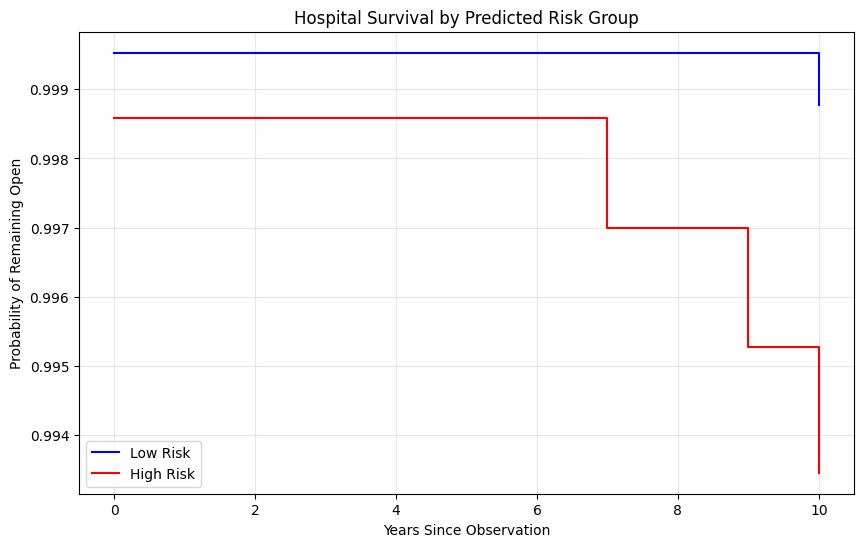

In [43]:
#initialize the kaplan meir survival model
kmf = KaplanMeierFitter()
#create a plot
plt.figure(figsize=(10, 6))
#loop through each risk group
for group, color in zip(["Low Risk","High Risk"],["blue","red"]):
    mask = hospital_survival_df["risk_group"] == group
    kmf.fit(durations = hospital_survival_df.loc[mask,"time_to_event"],
            event_observed=hospital_survival_df.loc[mask,"event"],
            label = group)
    kmf.plot_survival_function(ci_show=False,color=color)
#format plot
plt.title("Hospital Survival by Predicted Risk Group")
plt.xlabel("Years Since Observation")
plt.ylabel("Probability of Remaining Open")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

The above chart shows that high risk hospitals are identified by the model as having a significantly  lower probability of remaining open over time compared to low risk hospitals\. This shows the model effectively captures early warning signals of closure\. 

## Primary Random Forest Classifier Feature Importance 

In [44]:
#create a dataframe linking each feature with importance scores
rf_importance = pd.DataFrame({"feature": primary_feature_names,
                                "importance":rf_model_primary.feature_importances_})
#sort features by importance
rf_importance = rf_importance.sort_values("importance", ascending=False)
#remove noisy variables
exclude_patterns = ["STATE","ZIP","FIPS","SSA","CITY","RGN"]
#loop through each feature and verify it should be kept
filtered_rf = []
for i in range(len(rf_importance)):
    feature = rf_importance.iloc[i]["feature"]
    keep = True
    for pattern in exclude_patterns:
        if pattern in feature:
            keep = False
    if keep:
        filtered_rf.append(rf_importance.iloc[i])
#convert results into a dataframe
filtered_rf = pd.DataFrame(filtered_rf)
#keep top 15
top_features = filtered_rf.head(15)
top_features

,feature,importance
82,Net Income,0.025402
97,operating_margin,0.023464
79,Total Other Income,0.020604
33,Total Salaries (adjusted),0.020582
80,Total Income,0.020000
28,Total Costs,0.018780
53,Total Assets,0.017900
35,Cash on Hand and in Banks,0.017003
76,Net Patient Revenue,0.016924
66,Total Liabilities and Fund Balances,0.016521


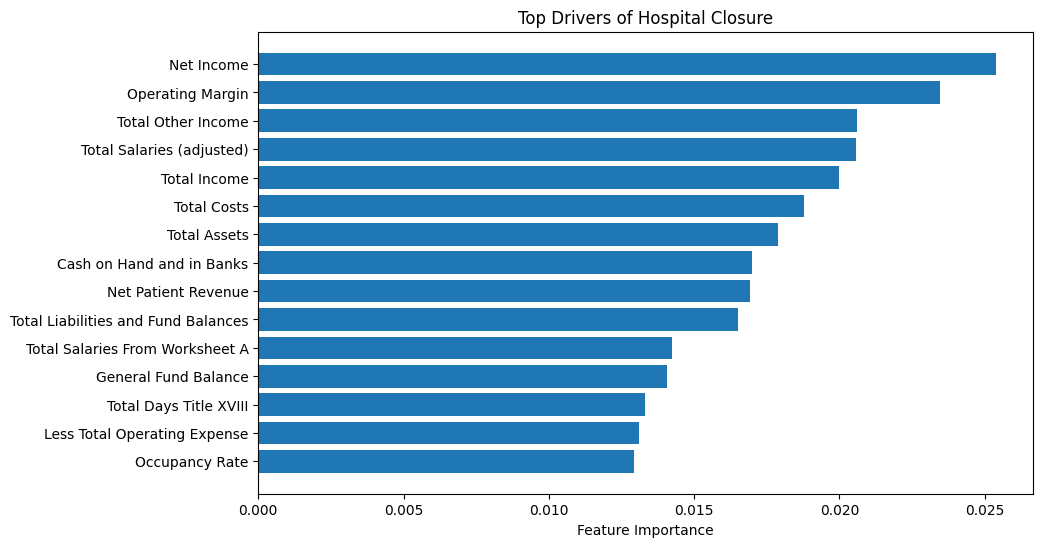

In [45]:
#sort from high to low on importance
top_features_sorted = top_features.sort_values("importance")
#upgrade name to be more readable
pretty_names = {"operating_margin": "Operating Margin",
                "total_margin": "Total Margin",
                "cost_to_revenue": "Cost to Revenue",
                "current_ratio": "Current Ratio",
                "cash_ratio": "Cash Ratio",
                "debt_ratio": "Debt Ratio",
                "occupancy_rate": "Occupancy Rate",
                "avg_length_of_stay": "Average Length of Stay",
                "medicaid_share": "Medicaid Share",
                "uncompensated_care_ratio": "Uncompensated Care Ratio",
                "labor_cost_ratio": "Labor Cost"}
top_features_sorted["pretty_features"] = top_features_sorted["feature"].map(pretty_names).fillna(top_features_sorted["feature"])
#format plot
plt.figure(figsize=(10, 6))
plt.barh(top_features_sorted["pretty_features"], top_features_sorted["importance"])
plt.title("Top Drivers of Hospital Closure")
plt.xlabel("Feature Importance")
plt.show()

## Key Ratios: High vs Low Risk Hospital Comparison

In [46]:
#create a comparison of features between high/low risk hospitals
comparison_df = primary_test_df.copy()
#add model predictions
comparison_df["prediction"] = y_pred_rf_primary_final
#key ratios
focus_cols = ["operating_margin",
                "total_margin",
                "cost_to_revenue",
                "current_ratio",
                "cash_ratio",
                "debt_ratio",
                "occupancy_rate",
                "avg_length_of_stay",
                "medicaid_share",
                "uncompensated_care_ratio",
                "labor_cost_ratio"]
#keep key ratios only
comparison_focus = comparison_df[focus_cols+["prediction"]].copy()
#create a standardized scale for key ratios
for col in focus_cols:
    mean_val = comparison_focus[col].mean()
    std_val = comparison_focus[col].std()
    comparison_focus[col] = (comparison_focus[col]-mean_val)/std_val
#define high/low risk
high_risk = comparison_focus[comparison_focus["prediction"] == 1]
low_risk = comparison_focus[comparison_focus["prediction"] == 0]
#calc standardized value for each key ratio
comparison = pd.DataFrame({"high_risk_mean": high_risk[focus_cols].mean(),
                            "low_risk_mean": low_risk[focus_cols].mean()})
#calc difference 
comparison["difference"] = comparison["high_risk_mean"] - comparison["low_risk_mean"]
#sort values
comparison = comparison.sort_values("difference", ascending=False)

comparison

,high_risk_mean,low_risk_mean,difference
cost_to_revenue,0.509326,-0.060922,0.570249
uncompensated_care_ratio,0.270127,-0.031853,0.301979
debt_ratio,0.232080,-0.027892,0.259972
medicaid_share,0.195859,-0.022946,0.218804
avg_length_of_stay,0.154379,-0.017974,0.172353
cash_ratio,0.007351,-0.000878,0.008229
current_ratio,0.006128,-0.000735,0.006863
labor_cost_ratio,-0.011695,0.001608,-0.013303
total_margin,-0.042270,0.004996,-0.047265
operating_margin,-0.283053,0.033842,-0.316895


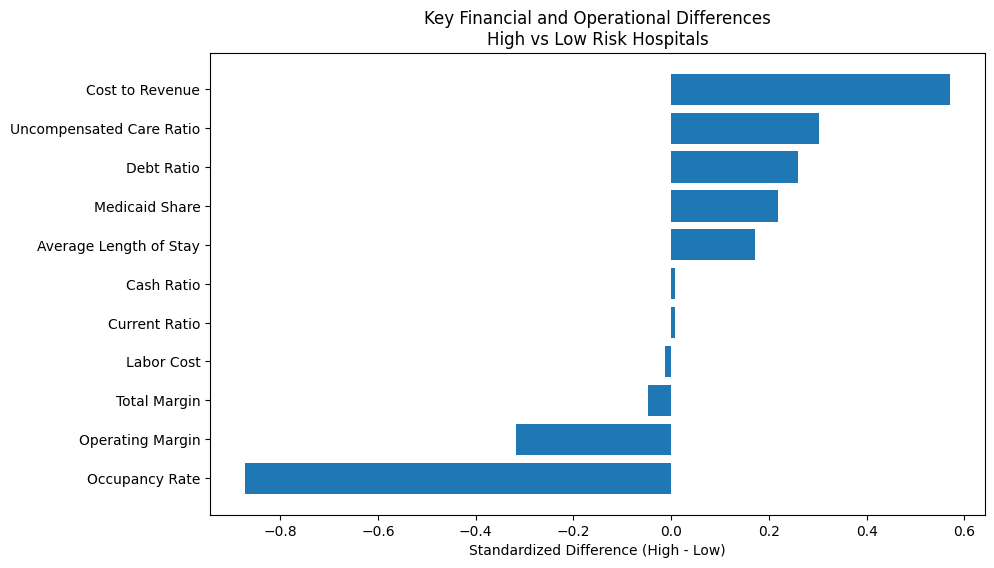

In [47]:
#sort values high to low
top_diff = comparison.sort_values("difference")
#upgrade names to be more readable
pretty_names = {"operating_margin": "Operating Margin",
                "total_margin": "Total Margin",
                "cost_to_revenue": "Cost to Revenue",
                "current_ratio": "Current Ratio",
                "cash_ratio": "Cash Ratio",
                "debt_ratio": "Debt Ratio",
                "occupancy_rate": "Occupancy Rate",
                "avg_length_of_stay": "Average Length of Stay",
                "medicaid_share": "Medicaid Share",
                "uncompensated_care_ratio": "Uncompensated Care Ratio",
                "labor_cost_ratio": "Labor Cost"}
top_diff.index = [pretty_names.get(idx,idx) for idx in top_diff.index]
#format table
plt.figure(figsize=(10, 6))
plt.barh(top_diff.index, top_diff["difference"])
plt.title(f"Key Financial and Operational Differences\n" 
            f"High vs Low Risk Hospitals")
plt.xlabel("Standardized Difference (High - Low)")
plt.show()

## Reimbursement Type

In [48]:
#create a reimbursement type dataframe
reimb_df = merged_df.copy()
#create 6 categories
reimb_df["category_group"] = "Other"
reimb_df.loc[reimb_df["PRVDR_CTGRY_SBTYP_CD"] == 11, "category_group"] = "CAH (Cost Based)"
reimb_df.loc[reimb_df["PRVDR_CTGRY_SBTYP_CD"] == 1, "category_group"] = "Short Term (PPS)"
reimb_df.loc[reimb_df["PRVDR_CTGRY_SBTYP_CD"] == 2, "category_group"] = "Long Term"
reimb_df.loc[reimb_df["PRVDR_CTGRY_SBTYP_CD"] == 4, "category_group"] = "Psychiatric"
reimb_df.loc[reimb_df["PRVDR_CTGRY_SBTYP_CD"] == 5, "category_group"] = "Rehabilitation"
reimb_df.loc[reimb_df["PRVDR_CTGRY_SBTYP_CD"] == 28, "category_group"] = "Rural Emergency"
#hospitals from 2020 and later
category_risk = reimb_df[reimb_df["year"] >= 2020].copy()
#add risk from primary model
category_risk["predicted_risk"] = y_prob_rf_primary
#summarize closure rates and average predicted risk by category
category_summary = (category_risk.groupby("category_group")
                                .agg(hospitals = ("Provider CCN", "nunique"),
                                hospital_years = ("Provider CCN", "count"),
                                closure_rate_1yr = ("closed_within_1yr", "mean"),
                                closure_rate_2yr = ("closed_within_2yr", "mean"),
                                avg_predicted_risk = ("predicted_risk", "mean")).reset_index())
#remove small categories
category_summary = category_summary[category_summary["hospitals"] >= 50]
#sort values
category_summary = category_summary.sort_values("closure_rate_1yr", ascending=False)

category_summary

,category_group,hospitals,hospital_years,closure_rate_1yr,closure_rate_2yr,avg_predicted_risk
6,Short Term (PPS),1418,4906,0.001427,0.002446,0.066754
0,CAH (Cost Based),1285,5015,0.001396,0.002592,0.070783
3,Psychiatric,71,256,0.000000,0.000000,0.084106


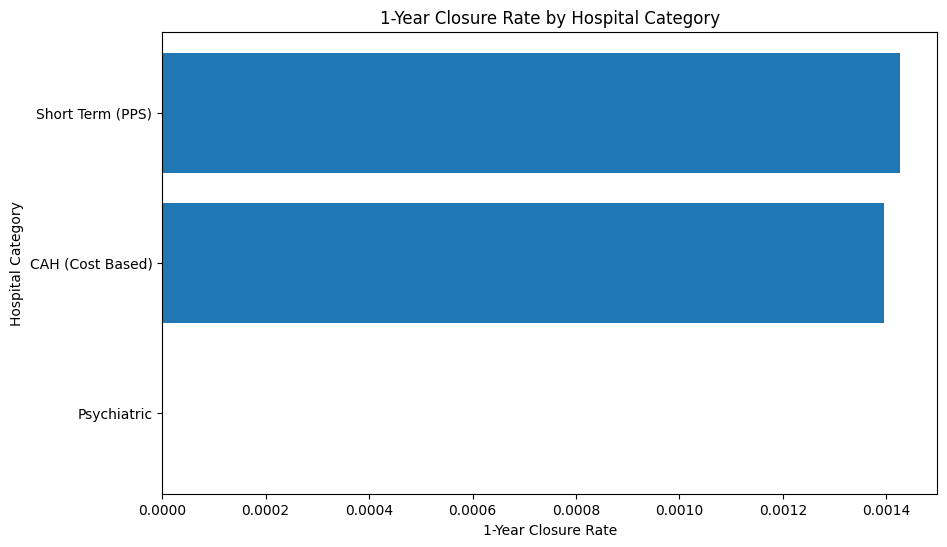

In [49]:
#format plot
plt.figure(figsize=(10, 6))
plt.barh(category_summary["category_group"], category_summary["closure_rate_1yr"])
plt.title("1-Year Closure Rate by Hospital Category")
plt.xlabel("1-Year Closure Rate")
plt.ylabel("Hospital Category")
plt.gca().invert_yaxis()
plt.show()

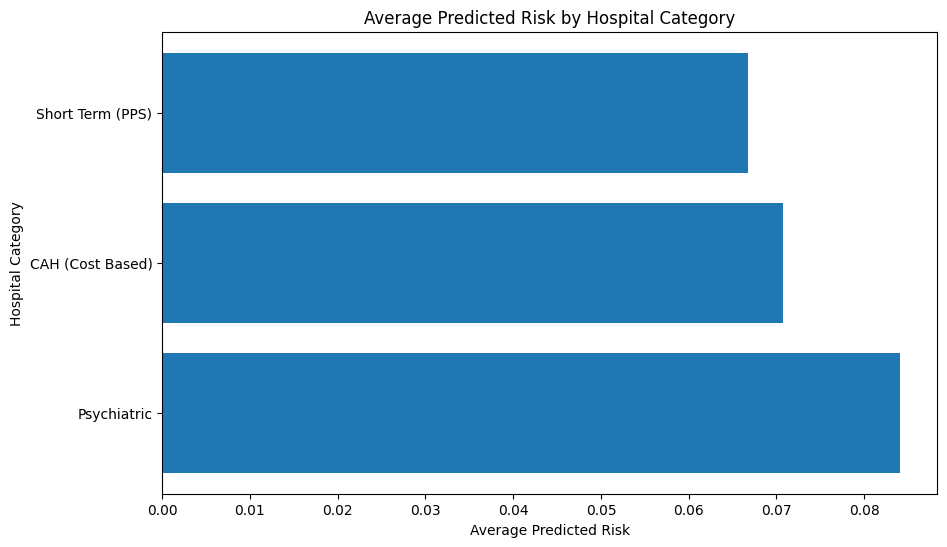

In [50]:
#format plot
plt.figure(figsize=(10, 6))
plt.barh(category_summary["category_group"], category_summary["avg_predicted_risk"])
plt.title("Average Predicted Risk by Hospital Category")
plt.xlabel("Average Predicted Risk")
plt.ylabel("Hospital Category")
plt.gca().invert_yaxis()
plt.show()

## Output Example

In [51]:
#hospitals from 2020 and later
hospital_examples = merged_df[merged_df["year"] >= 2020][["Provider CCN","Hospital Name","year","Closure Year"]].copy()
#reset index
hospital_examples = hospital_examples.reset_index(drop=True)
#add risk score and prediction flag from primary model
hospital_examples["risk_score"] = y_prob_rf_primary
hospital_examples["predicted_flag"] = y_pred_rf_primary_final
#sort values from high risk per hospital
hospital_examples = hospital_examples.sort_values(["Provider CCN","risk_score"], ascending=[True, False])
#keep only the highest risk
hospital_examples = hospital_examples.groupby("Provider CCN").first().reset_index()
#keep only hospitals that have not closed
hospital_examples = hospital_examples[hospital_examples["Closure Year"].isna()]
#define risk categories high/med/low
conditions = [hospital_examples["risk_score"] >= 0.2,
                hospital_examples["risk_score"] >= 0.05]
choices = ["High Risk","Medium Risk"]
hospital_examples["risk_group"] = np.select(conditions,choices, default = "Low Risk")
#keep top 5 for each risk category
high_examples = hospital_examples[hospital_examples["risk_group"] == "High Risk"].copy()
high_examples = high_examples.sort_values("risk_score", ascending=False).head(5)

med_examples = hospital_examples[hospital_examples["risk_group"] == "Medium Risk"].copy()
med_examples = med_examples.sort_values("risk_score", ascending=False).head(5)

low_examples = hospital_examples[hospital_examples["risk_group"] == "Low Risk"].copy()
low_examples = low_examples.sort_values("risk_score", ascending=True).head(5)
#combine the examples
example_hospitals = pd.concat([high_examples, med_examples, low_examples], ignore_index=True)
#create a display name for better readability
example_hospitals["display_name"] =  (example_hospitals["Hospital Name"].astype(str)
                                        + " | CCN: "
                                        + example_hospitals["Provider CCN"].astype(str)
                                        + " | " 
                                        + example_hospitals["risk_group"])
#sort table
example_hospitals = example_hospitals.sort_values(["risk_score"], ascending=False).reset_index(drop=True)

print(example_hospitals[["Hospital Name","risk_group","risk_score"]])

                           Hospital Name   risk_group  risk_score
0          BIG SOUTH FORK MEDICAL CENTER    High Risk    0.600180
1                PERRY MEMORIAL HOSPITAL    High Risk    0.547679
2                  IRWIN COUNTY HOSPITAL    High Risk    0.536455
3              ST THOMAS DEKALB HOSPITAL    High Risk    0.534136
4               ALLIANCE HEALTH SEMINOLE    High Risk    0.512595
5             OCHSNER SPECIALTY HOSPITAL  Medium Risk    0.199504
6                 CONCHO COUNTY HOSPITAL  Medium Risk    0.199185
7     MERCYONE DYERSVILLE MEDICAL CENTER  Medium Risk    0.199103
8         DOROTHEA DIX BEHAVIORAL HEALTH  Medium Risk    0.198640
9               NORTHWEST MEDICAL CENTER  Medium Risk    0.198612
10                SHANNON MEDICAL CENTER     Low Risk    0.008366
11  UNIVERSITY OF IOWA HEALTH CARE MEDIC     Low Risk    0.007161
12         IOWA METHODIST MEDICAL CENTER     Low Risk    0.007068
13  UNIVERSITY OF WI HOSPITALS & CLINICS     Low Risk    0.006119
14        

In [52]:
#build hospital level feature table
X_test_primary_rf_df = pd.DataFrame(X_test_primary_rf, columns = primary_feature_names).reset_index(drop=True).reset_index(drop=True)
#hospitals from 2020 and later
test_row_keys = merged_df[merged_df["year"] >= 2020][["Provider CCN","Hospital Name","year"]].reset_index(drop=True)
#combine hospital with model features
hospital_feature_rows = pd.concat([test_row_keys,X_test_primary_rf_df], axis = 1)
#add risk/prediction
hospital_feature_rows["risk_score"] = y_prob_rf_primary
hospital_feature_rows["predicted_flag"] = y_pred_rf_primary_final
#sort so high risk per hopsital comes first
hospital_feature_rows = hospital_feature_rows.sort_values(["Provider CCN","risk_score"], ascending=[True,False])
#keep highest risk only
hospital_feature_rows = hospital_feature_rows.groupby("Provider CCN").first().reset_index()
#calc avaerage values
average_features = hospital_feature_rows[primary_feature_names].mean()
#key ratios
focus_cols = ["operating_margin",
                "total_margin",
                "cost_to_revenue",
                "current_ratio",
                "cash_ratio",
                "debt_ratio",
                "occupancy_rate",
                "avg_length_of_stay",
                "medicaid_share",
                "uncompensated_care_ratio",
                "labor_cost_ratio"]

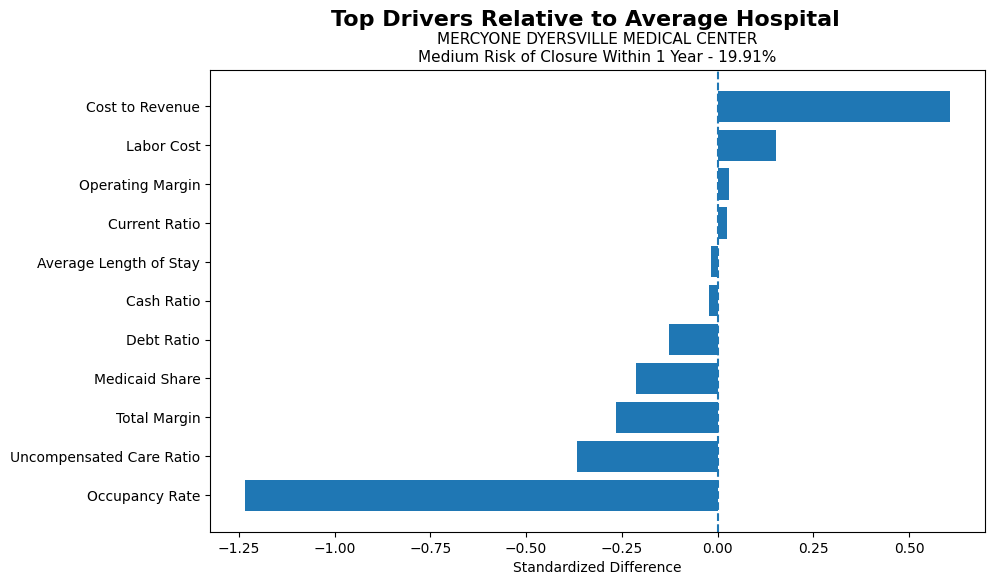

In [53]:
#choose hospital to inspect
hosp_name = "MERCYONE DYERSVILLE MEDICAL CENTER"
#identify hospital feature table
selected_meta = example_hospitals[example_hospitals["Hospital Name"] == hosp_name].copy()
selected_row = hospital_feature_rows[hospital_feature_rows["Hospital Name"] == hosp_name].copy()
#stop if hospital is not found
if selected_row.empty:
    print(f"Hospital not found: {hosp_name}")
else:
    selected_row = selected_row.iloc[0]
    if selected_meta.empty:
        print(f"Hospital not found: {hosp_name}")
    else:
        selected_meta = selected_meta.iloc[0]
    #compare hospital feature with average hospital
    compare_df = pd.DataFrame({"hospital_value": selected_row[focus_cols],
                            "average_value": average_features[focus_cols]})
    #calc difference from average hospital
    compare_df["difference"] = compare_df["hospital_value"] - compare_df["average_value"]
    #standardize the differences in features for better comparison
    std_vals = hospital_feature_rows[focus_cols].std().replace(0, np.nan)
    compare_df["z_difference"] = compare_df["difference"]/std_vals
    #clean invalid values
    compare_df = compare_df.replace([np.inf,-np.inf], np.nan).dropna()
    compare_df = compare_df.sort_values("z_difference")

pretty_names = {"operating_margin": "Operating Margin",
                "total_margin": "Total Margin",
                "cost_to_revenue": "Cost to Revenue",
                "current_ratio": "Current Ratio",
                "cash_ratio": "Cash Ratio",
                "debt_ratio": "Debt Ratio",
                "occupancy_rate": "Occupancy Rate",
                "avg_length_of_stay": "Average Length of Stay",
                "medicaid_share": "Medicaid Share",
                "uncompensated_care_ratio": "Uncompensated Care Ratio",
                "labor_cost_ratio": "Labor Cost"}

plot_df = compare_df.copy()
plot_df.index = [pretty_names.get(idx,idx) for idx in plot_df.index]
#format plot
plt.figure(figsize=(10, 6))
plt.barh(plot_df.index, plot_df["z_difference"])
plt.axvline(0, linestyle = "--")
plt.suptitle("Top Drivers Relative to Average Hospital",
                fontsize = 16,
                fontweight = "bold")
plt.title(f"{selected_meta['Hospital Name']}\n"
            f"{selected_meta['risk_group']} of Closure Within 1 Year - {selected_meta['risk_score']*100:.2f}%",
            fontsize = 11)
plt.xlabel("Standardized Difference")
plt.show()

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=6487bd77-f95c-49fb-89f2-1da3f5539b23' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>